<a href="https://colab.research.google.com/github/carlavilla/GIS/blob/main/PS3_GIS_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supernatural beliefs across the United States
Mapping out sightings/ and reported beliefs in the supernatural to determine the spookiest state. </br>

##Hypothesis:
At least one state will be among the top in spooky sightings or beliefs.

##Next steps:
- map top states
- map city sightings

## Possible variables to include:
*   Mental Health
*   Openness to experience scale
*   Belief in UFO
*   Folklore, creatures, legends
*   Cults
*   Native American territories
*   Spirituality
*   Politics: maybe look at 2024 election popular vote percentages

#Environment Set up

In [1]:
!pip install mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 9.8 MB/s eta 0:00:00


In [2]:
import os, zipfile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

import mapclassify

import seaborn as sns


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files

from google.colab.data_table import DataTable
DataTable.max_columns = 250

#Dataset 1: UFO Sightings in the US
UFO sighting reports to the National UFO Reporting Center for the year 2024. </br>

Source: [NUFORC Databank](https://nuforc.org/databank/) </br>
Data was sorted for USA sighting reports on the website and recorded onto an excel spreadsheet for this project. Since my interest is in attitudes towards UFO sightings in a given year, this dataset contains reports made in 2024, regardless of the actual supposed sighting of the object. That means that some of the sightings are from previous years and they were only reported in 2024; conversely, some of the sightings claimed to have occurred in 2024 are not included in this dataset and they were reported in 2025. Other interesting variables include date of sighting, city of report, shape of object, and alternative explanation for event. Although some events appear to be disproven, all reports are used as indicative of supernatural beliefs. </br>

##UFO Sighting Reports dataset comments:
Since dataset includes single entries of reports, the count for the number of reports in each state in 2024 was calculated. This count appears in python as a series, but this series will be used as the variable to merge with the map. </br>

**Top 10 states** for UFO reports in 2024: California (418), Florida (244), Texas (228), New York (221), Washington (190), Arizona (175), Pennsylvania (157), Colorado (137), North Carolina (125), Michigan (117).

In [3]:
! wget -q -O ufo2024.xlsx https://raw.githubusercontent.com/carlavilla/GIS/main/ufo2024.xlsx
ufo=pd.read_excel('ufo2024.xlsx', engine='openpyxl')

In [4]:
ufo=pd.read_excel('ufo2024.xlsx', engine='openpyxl')

In [5]:
ufo.head(5)

,Occurred,City,State,Country,Shape,Summary,Reported,Media,Explanation
0,2024-12-15 17:00:00,Chatanika,AK,USA,Formation,Saw 3 non moving lights that disappeared one a...,2024-12-31,NaN,NaN
1,2024-12-28 08:01:00,Meadow Lakes,AK,USA,Circle,Observed flashing light (after larger plane we...,2024-12-28,Y,Drone
2,2024-12-13 20:00:00,NaN,AK,USA,Chevron,Large V shaped triangle with white lights,2024-12-25,NaN,NaN
3,2024-12-19 23:30:00,Trapper Creek,AK,USA,Oval,Green glowing oval object the size of a school...,2024-12-24,Y,NaN
4,2024-11-02 23:30:00,Fox,AK,USA,Orb,Floating light that accelerated downwards into...,2024-12-22,NaN,NaN


In [6]:
ufo.rename(columns={'State': 'state'}, inplace=True)
#I kept getting an error when I tried doing the count by state. When I used Gemini to check, it identified that the variable is named "State\xa0" even though it didnt show in the header or info.

In [7]:
ufo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4034 entries, 0 to 4033
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Occurred     4034 non-null   datetime64[ns]
 1   City         3974 non-null   object        
 2   state        4034 non-null   object        
 3   Country      4034 non-null   object        
 4   Shape        4032 non-null   object        
 5   Summary      4034 non-null   object        
 6   Reported     4034 non-null   datetime64[ns]
 7   Media        1589 non-null   object        
 8   Explanation  1007 non-null   object        
dtypes: datetime64[ns](2), object(7)
memory usage: 283.8+ KB


In [8]:
#getting the count by state
from collections import Counter
ufocount = ufo['state'].value_counts()
print(ufocount)
#Non-state rows will be removed during merging

state
CA    418
FL    244
TX    228
NY    221
WA    190
AZ    175
PA    157
CO    137
NC    125
MI    117
OH    113
NJ    101
OR     98
MA     96
GA     91
VA     91
IL     87
MN     83
TN     75
IN     69
SC     62
WI     61
KY     60
UT     60
MD     60
MO     59
CT     54
ID     54
OK     51
AL     50
NV     50
LA     47
NM     46
ME     45
KS     39
MT     37
AR     35
IA     34
WV     31
MS     28
NH     25
SD     20
AK     18
VT     18
NE     18
DE     17
RI     15
HI     11
WY      6
DC      5
ND      2
Name: count, dtype: int64


<BarContainer object of 24 artists>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, 'Orb'),
  Text(1, 0, 'Light'),
  Text(2, 0, 'Circle'),
  Text(3, 0, 'Triangle'),
  Text(4, 0, 'Unknown'),
  Text(5, 0, 'Other'),
  Text(6, 0, 'Changing'),
  Text(7, 0, 'Disk'),
  Text(8, 0, 'Sphere'),
  Text(9, 0, 'Oval'),
  Text(10, 0, 'Cigar'),
  Text(11, 0, 'Cylinder'),
  Text(12, 0, 'Rectangle'),
  Text(13, 0, 'Formation'),
  Text(14, 0, 'Fireball'),
  Text(15, 0, 'Star'),
  Text(16, 0, 'Chevron'),
  Text(17, 0, 'Diamond'),
  Text(18, 0, 'Flash'),
  Text(19, 0, 'Cube'),
  Text(20, 0, 'Cone'),
  Text(21, 0, 'Teardrop'),
  Text(22, 0, 'Egg'),
  Text(23, 0, 'Cross')])

Text(0.5, 0, 'Shape')

Text(0, 0.5, 'Count')

Text(0.5, 1.0, 'UFO Shape Count')

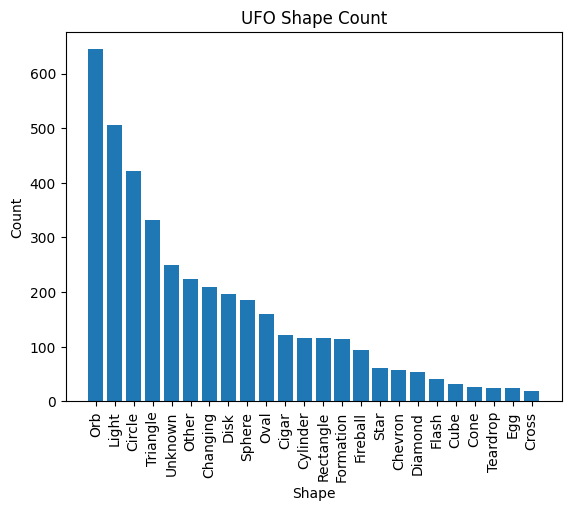

In [9]:
ufoshapecount = ufo['Shape'].value_counts()
plt.bar(ufoshapecount.index, ufoshapecount.values)
plt.xticks(rotation=90)
plt.xlabel("Shape")
plt.ylabel("Count")
plt.title("UFO Shape Count")
plt.show()

<Figure size 1200x600 with 0 Axes>

<BarContainer object of 51 artists>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50],
 [Text(0, 0, 'CA'),
  Text(1, 0, 'FL'),
  Text(2, 0, 'TX'),
  Text(3, 0, 'NY'),
  Text(4, 0, 'AZ'),
  Text(5, 0, 'WA'),
  Text(6, 0, 'PA'),
  Text(7, 0, 'NC'),
  Text(8, 0, 'CO'),
  Text(9, 0, 'NJ'),
  Text(10, 0, 'OH'),
  Text(11, 0, 'IL'),
  Text(12, 0, 'VA'),
  Text(13, 0, 'MI'),
  Text(14, 0, 'GA'),
  Text(15, 0, 'MA'),
  Text(16, 0, 'OR'),
  Text(17, 0, 'IN'),
  Text(18, 0, 'MN'),
  Text(19, 0, 'TN'),
  Text(20, 0, 'NV'),
  Text(21, 0, 'MO'),
  Text(22, 0, 'KY'),
  Text(23, 0, 'CT'),
  Text(24, 0, 'UT'),
  Text(25, 0, 'WI'),
  Text(26, 0, 'ME'),
  Text(27, 0, 'NM'),
  Text(28, 0, 'SC'),
  Text(29, 0, 'KS'),
  Text(30, 0, 'LA'),
  Text(31, 0, 'MD'),
  Text(32, 0, 'AL'),
  Text(33, 0, 'AR'),

Text(0.5, 0, 'State')

Text(0, 0.5, 'Count of Sightings with Media')

Text(0.5, 1.0, 'UFO Sightings with Media by State (2024)')

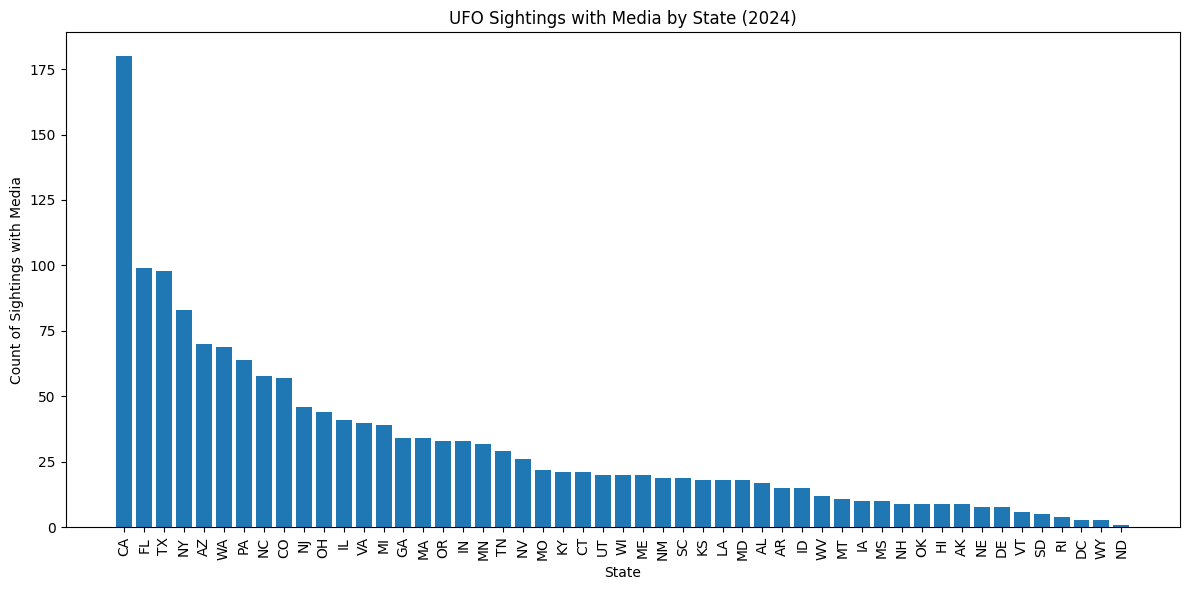

In [91]:
ufo_media = ufo[ufo['Media'] == 'Y']
ufomedia_count = ufo_media['state'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(ufomedia_count.index, ufomedia_count.values)
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Count of Sightings with Media")
plt.title("UFO Sightings with Media by State (2024)")
plt.tight_layout()
plt.show()

#Dataset 2: Haunted Places in the US
Haunted places in the US as recorded in the [Shadowlands Haunted Places Index](https://www.theshadowlands.net/places/), last updated in 2020.

Source: [Github Tidy Tuesday Database](https://github.com/rfordatascience/tidytuesday/blob/main/data/2023/2023-10-10/readme.md) </br>
Data was gathered by user [Tim Renner](https://github.com/timothyrenner/shadowlands-haunted-places) for a tidytuesday challenge. Other interesting variables include description of haunting/place, city, and latitutde/longitude of place.

##Haunted Places dataset comments:
Since dataset includes single entries of haunted places, the count for the number of places in each state was calculated. This count appears in python as a series, but this series will be used as the variable to merge with the map.

**Top 10 states** with haunted places: California (1070), Texas (696), Pennsylvania (649), Michigan (529), Ohio (477), New York, Illinois, Kentucky, Indiana, and Massachussetts.

In [17]:
haunted=pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-10/haunted_places.csv')

In [18]:
haunted.head(5)

,city,country,description,location,state,state_abbrev,longitude,latitude,city_longitude,city_latitude
0,Ada,United States,Ada witch - Sometimes you can see a misty blue...,Ada Cemetery,Michigan,MI,-85.504893,42.962106,-85.495480,42.960727
1,Addison,United States,A little girl was killed suddenly while waitin...,North Adams Rd.,Michigan,MI,-84.381843,41.971425,-84.347168,41.986434
2,Adrian,United States,If you take Gorman Rd. west towards Sand Creek...,Ghost Trestle,Michigan,MI,-84.035656,41.904538,-84.037166,41.897547
3,Adrian,United States,"In the 1970's, one room, room 211, in the old ...",Siena Heights University,Michigan,MI,-84.017565,41.905712,-84.037166,41.897547
4,Albion,United States,Kappa Delta Sorority - The Kappa Delta Sororit...,Albion College,Michigan,MI,-84.745177,42.244006,-84.753030,42.243097


In [19]:
haunted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            10989 non-null  object 
 1   country         10992 non-null  object 
 2   description     10992 non-null  object 
 3   location        10989 non-null  object 
 4   state           10992 non-null  object 
 5   state_abbrev    10992 non-null  object 
 6   longitude       9731 non-null   float64
 7   latitude        9731 non-null   float64
 8   city_longitude  10963 non-null  float64
 9   city_latitude   10963 non-null  float64
dtypes: float64(4), object(6)
memory usage: 858.9+ KB


In [20]:
haunted.rename(columns={'state': 'state_name'}, inplace=True)
haunted.rename(columns={'state_abbrev': 'state'}, inplace=True)
#changing variable names so they can be used for merging later

In [21]:
haunted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            10989 non-null  object 
 1   country         10992 non-null  object 
 2   description     10992 non-null  object 
 3   location        10989 non-null  object 
 4   state_name      10992 non-null  object 
 5   state           10992 non-null  object 
 6   longitude       9731 non-null   float64
 7   latitude        9731 non-null   float64
 8   city_longitude  10963 non-null  float64
 9   city_latitude   10963 non-null  float64
dtypes: float64(4), object(6)
memory usage: 858.9+ KB


In [22]:
hauntedcount = haunted['state'].value_counts()
print(hauntedcount)

state
CA    1070
TX     696
PA     649
MI     529
OH     477
NY     459
IL     395
KY     370
IN     351
MA     342
FL     328
MO     314
GA     289
WI     274
AL     224
TN     221
WA     218
NC     211
OK     211
NJ     194
VA     192
CT     185
MD     170
IA     169
SC     168
CO     166
MN     162
AZ     156
OR     155
UT     134
KS     123
AR     119
NE     111
WV     106
LA      99
HI      96
NM      78
WY      76
SD      75
NH      72
RI      68
ID      66
VT      63
MS      63
ND      58
ME      57
NV      56
MT      42
DE      37
AK      32
DC      16
Name: count, dtype: int64


#Dataset 3: Long Term Vacancies
Source: U.S. Census American Household Survey
Dataset contains property vacancies estimates for the year 2024. </br>
Vacancies are defined as the absence of inhabitants in a residential property for any reasons including but not limited to being up for sale, up for rent, or uninhabitable. The dataset also contains counts sorted by length of vacancy (1, 2, 3, 6, 12, and over 24 months). </br>

##Long-Term Vacancies dataset comments:
Since the vacancy of a property could be due to a variety of nonspooky reasons, I will be using specifically the count of properties with the longest vacancies (over 24 months) under the assumption that there may be more unusual circumstances around these properties that prevent them from becoming occupied.

In [23]:
! wget -q -O VacancyLength2024.csv https://raw.githubusercontent.com/carlavilla/GIS/main/VacancyLength2024.csv
vacancy2024=pd.read_csv('VacancyLength2024.csv')

In [24]:
vacancy2024.rename(columns={'NAME': 'state_name', 'B25131_008E': "Vacant24MO"}, inplace=True)

In [25]:
vacancy2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GEO_ID       53 non-null     object 
 1   state_name   53 non-null     object 
 2   B25131_001E  53 non-null     object 
 3   B25131_001M  53 non-null     object 
 4   B25131_002E  53 non-null     object 
 5   B25131_002M  53 non-null     object 
 6   B25131_003E  53 non-null     object 
 7   B25131_003M  53 non-null     object 
 8   B25131_004E  53 non-null     object 
 9   B25131_004M  53 non-null     object 
 10  B25131_005E  53 non-null     object 
 11  B25131_005M  53 non-null     object 
 12  B25131_006E  53 non-null     object 
 13  B25131_006M  53 non-null     object 
 14  B25131_007E  53 non-null     object 
 15  B25131_007M  53 non-null     object 
 16  Vacant24MO   53 non-null     object 
 17  B25131_008M  53 non-null     object 
 18  Unnamed: 18  0 non-null      float64
dtypes: float64

In [26]:
vacancy2024['Vacant24MO'] = pd.to_numeric(vacancy2024['Vacant24MO'], errors='coerce')
vacancy2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GEO_ID       53 non-null     object 
 1   state_name   53 non-null     object 
 2   B25131_001E  53 non-null     object 
 3   B25131_001M  53 non-null     object 
 4   B25131_002E  53 non-null     object 
 5   B25131_002M  53 non-null     object 
 6   B25131_003E  53 non-null     object 
 7   B25131_003M  53 non-null     object 
 8   B25131_004E  53 non-null     object 
 9   B25131_004M  53 non-null     object 
 10  B25131_005E  53 non-null     object 
 11  B25131_005M  53 non-null     object 
 12  B25131_006E  53 non-null     object 
 13  B25131_006M  53 non-null     object 
 14  B25131_007E  53 non-null     object 
 15  B25131_007M  53 non-null     object 
 16  Vacant24MO   52 non-null     float64
 17  B25131_008M  53 non-null     object 
 18  Unnamed: 18  0 non-null      float64
dtypes: float64

In [27]:
vacancy2024.head(5)

,GEO_ID,state_name,B25131_001E,B25131_001M,B25131_002E,B25131_002M,B25131_003E,B25131_003M,B25131_004E,B25131_004M,B25131_005E,B25131_005M,B25131_006E,B25131_006M,B25131_007E,B25131_007M,Vacant24MO,B25131_008M,Unnamed: 18
0,Geography,Geographic Area Name,Estimate!!Total:,Margin of Error!!Total:,Estimate!!Total:!!Less than 1 month,Margin of Error!!Total:!!Less than 1 month,Estimate!!Total:!!1 to 2 months,Margin of Error!!Total:!!1 to 2 months,Estimate!!Total:!!2 to 4 months,Margin of Error!!Total:!!2 to 4 months,Estimate!!Total:!!4 to 6 months,Margin of Error!!Total:!!4 to 6 months,Estimate!!Total:!!6 to 12 months,Margin of Error!!Total:!!6 to 12 months,Estimate!!Total:!!12 to 24 months,Margin of Error!!Total:!!12 to 24 months,NaN,Margin of Error!!Total:!!24 or more months,NaN
1,0400000US01,Alabama,322243,11723,72438,5262,33240,4421,30624,4131,25832,3055,34749,3791,35737,4249,89623.0,5279,NaN
2,0400000US02,Alaska,55712,3835,7299,1563,6618,1475,5882,1241,6310,1131,6156,1090,4256,1247,19191.0,1724,NaN
3,0400000US04,Arizona,316703,11630,72696,5327,59081,5278,57694,5105,40255,4766,35262,3945,16505,2791,35210.0,3172,NaN
4,0400000US05,Arkansas,174275,7627,18639,2854,19726,3400,21500,3328,16527,2975,26366,2948,17882,2709,53635.0,4315,NaN


<Figure size 1200x600 with 0 Axes>

<BarContainer object of 53 artists>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52],
 [Text(0, 0, 'Geographic Area Name'),
  Text(1, 0, 'Alabama'),
  Text(2, 0, 'Alaska'),
  Text(3, 0, 'Arizona'),
  Text(4, 0, 'Arkansas'),
  Text(5, 0, 'California'),
  Text(6, 0, 'Colorado'),
  Text(7, 0, 'Connecticut'),
  Text(8, 0, 'Delaware'),
  Text(9, 0, 'District of Columbia'),
  Text(10, 0, 'Florida'),
  Text(11, 0, 'Georgia'),
  Text(12, 0, 'Hawaii'),
  Text(13, 0, 'Idaho'),
  Text(14, 0, 'Illinois'),
  Text(15, 0, 'Indiana'),
  Text(16, 0, 'Iowa'),
  Text(17, 0, 'Kansas'),
  Text(18, 0, 'Kentucky'),
  Text(19, 0, 'Louisiana'),
  Text(20, 0, 'Maine'),
  Text(21, 0, 'Maryland'),
  Text(22, 0, 'Massachusetts'),
  Text(23, 0, 'Michigan'),
  Text(24, 0, 'Minnesota'),
  Text(25, 

Text(0.5, 0, 'State')

Text(0, 0.5, 'Number of Vacant Properties (24+ months)')

Text(0.5, 1.0, 'Long-Term Vacancies by State (2024)')

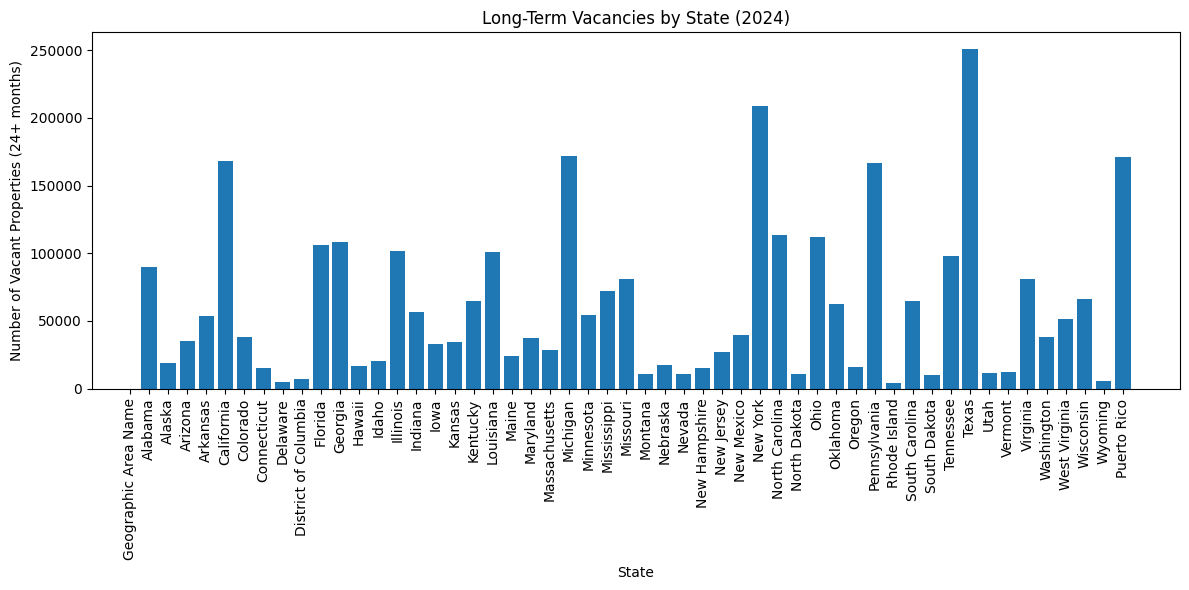

In [28]:
#Code below produced by Gemini before I changed Vacant24MO variable to numeric earlier.
# Remove the first row which contains descriptive text
#vacancy_data = vacancy2024.iloc[1:].copy()
# Convert the 'Vacant24MO' column to numeric, coercing errors
#vacancy_data['Vacant24MO'] = pd.to_numeric(vacancy_data['Vacant24MO'], errors='coerce')
# Drop any rows where 'Vacant24MO' is NaN after coercion
#vacancy_data = vacancy_data.dropna(subset=['Vacant24MO'])

plt.figure(figsize=(12, 6))
plt.bar(vacancy2024['state_name'], vacancy2024['Vacant24MO'])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Number of Vacant Properties (24+ months)")
plt.title("Long-Term Vacancies by State (2024)")
plt.tight_layout()
plt.show()

#Dataset 4: Population by State (2024)
Source: [United States Census Vintage 2024 data](https://www.census.gov/data/tables/time-series/demo/popest/2020s-state-total.html) </br>
Dataset contains population estemates for USA regions and states for years 2020 through 2024 based on the 2020 Census. Dataset also includes estimates for births, deaths, and migration changes.

##Population dataset comments:
I will mainly be using the population estimate for each state for the year 2024 to calculate the incidence per capita of the spooky variables.

In [29]:
! wget -q -O PopEst2024.csv https://raw.githubusercontent.com/carlavilla/GIS/main/PopEst2024.csv
pop2024=pd.read_csv('PopEst2024.csv')
#code corrected by Gemini due to error in url- original command referenced an html file (the usual type of file for those housed in GDrive) but this file is uploaded as a csv in GitHub.

In [30]:
pop2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 75 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SUMLEV                 66 non-null     int64  
 1   REGION                 66 non-null     object 
 2   DIVISION               66 non-null     object 
 3   state_name             66 non-null     object 
 4   state                  52 non-null     object 
 5   ESTIMATESBASE2020      66 non-null     int64  
 6   POPESTIMATE2020        66 non-null     int64  
 7   POPESTIMATE2021        66 non-null     int64  
 8   POPESTIMATE2022        66 non-null     int64  
 9   POPESTIMATE2023        66 non-null     int64  
 10  POPESTIMATE2024        66 non-null     int64  
 11  NPOPCHG_2020           66 non-null     int64  
 12  NPOPCHG_2021           66 non-null     int64  
 13  NPOPCHG_2022           66 non-null     int64  
 14  NPOPCHG_2023           66 non-null     int64  
 15  NPOPCHG_

In [31]:
pop2024.head(5)

,SUMLEV,REGION,DIVISION,state_name,state,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,...,RINTERNATIONALMIG2023,RINTERNATIONALMIG2024,RDOMESTICMIG2021,RDOMESTICMIG2022,RDOMESTICMIG2023,RDOMESTICMIG2024,RNETMIG2021,RNETMIG2022,RNETMIG2023,RNETMIG2024
0,10,0,0,United States,NaN,331515736,331577720,332099760,334017321,336806231,...,6.840246,8.231786,0.000000,0.000000,0.000000,0.000000,1.133093,5.084797,6.840246,8.231786
1,20,1,0,Northeast Region,NaN,57617706,57431458,57252533,57159597,57398303,...,8.175150,9.848371,-4.674375,-7.824957,-4.857718,-3.334322,-3.271477,-2.006798,3.317432,6.514050
2,30,1,1,New England,NaN,15122011,15057350,15118145,15175633,15263573,...,8.005202,9.622685,2.416795,-2.957175,-2.067991,-1.575091,4.188365,4.325839,5.937211,8.047594
3,30,1,2,Middle Atlantic,NaN,42495695,42374108,42134388,41983964,42134730,...,8.236647,9.930153,-7.206423,-9.578005,-5.867209,-3.971810,-5.935167,-4.287388,2.369438,5.958342
4,20,2,0,Midwest Region,NaN,68998970,68984258,68872831,68903297,69186401,...,4.859117,5.861482,-2.502867,-2.649762,-1.300416,-0.709222,-1.700819,0.891824,3.558701,5.152260


<Figure size 1200x600 with 0 Axes>

<BarContainer object of 66 artists>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65],
 [Text(0, 0, 'United States'),
  Text(1, 0, 'Northeast Region'),
  Text(2, 0, 'New England'),
  Text(3, 0, 'Middle Atlantic'),
  Text(4, 0, 'Midwest Region'),
  Text(5, 0, 'East North Central'),
  Text(6, 0, 'West North Central'),
  Text(7, 0, 'South Region'),
  Text(8, 0, 'South Atlantic'),
  Text(9, 0, 'East South Central'),
  Text(10, 0, 'West South Central'),
  Text(11, 0, 'West Region'),
  Text(12, 0, 'Mountain'),
  Text(13, 0, 'Pacific'),
  Text(14, 0, 'Alabama'),
  Text(15, 0, 'Alaska'),
  Text(16, 0, 'Arizona'),
  Text(17, 0, 'Arkansas'),
  Text(18, 0, 'California'),
  Text(19, 0, 'Colorado'),
  Te

Text(0.5, 0, 'State')

Text(0, 0.5, 'Population')

Text(0.5, 1.0, 'Population by State (2024)')

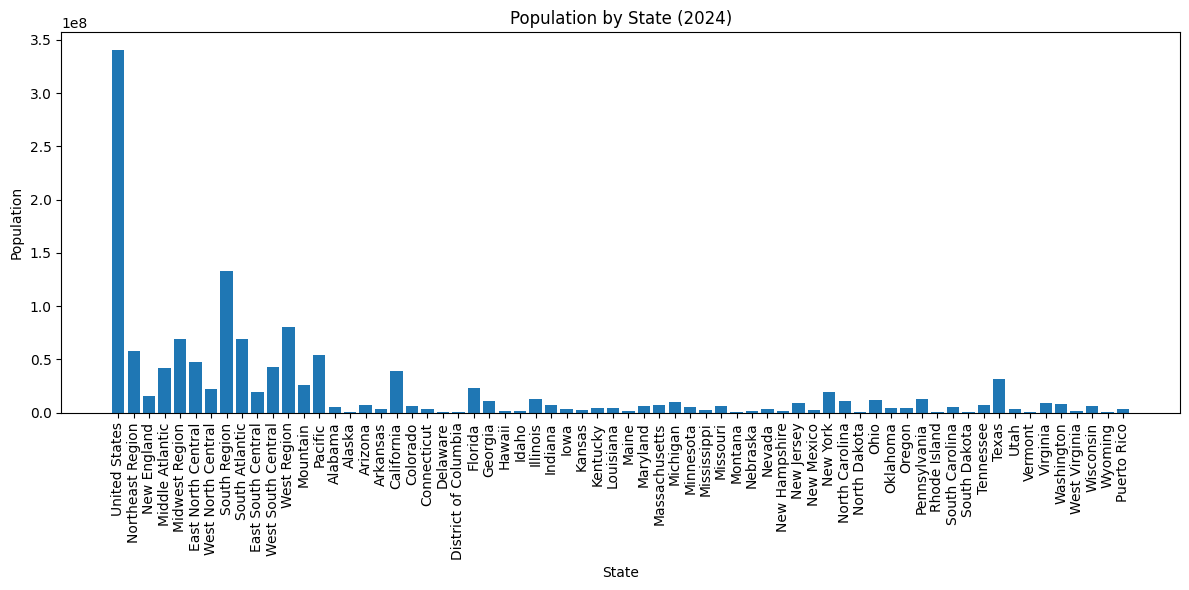

In [32]:
plt.figure(figsize=(12, 6))
plt.bar(pop2024['state_name'], pop2024['POPESTIMATE2024'])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Population")
plt.title("Population by State (2024)")
plt.tight_layout()
plt.show()

#Dataset 5: Total Area per State
Source: [Census State Area Measurements and Internal Point Coordinates](https://www.census.gov/geographies/reference-files/2010/geo/state-area.html) </br>
Dataset was published in 2010 and contains total area and per state area in square miles and kilometers. Dataset also has break down of land area, water area, coastal, inland, and other. </br>

##Area dataset comments:
I will be using this dataset to calculate the density of haunted places and vacant properties per state.

In [46]:
! wget -q -O StArea.xlsx https://raw.githubusercontent.com/carlavilla/GIS/main/StateArea2010.xlsx
area=pd.read_excel('StArea.xlsx')

In [47]:
area.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state_name                      51 non-null     object 
 1   state                           51 non-null     object 
 2   Total Area Sq.Mi.               51 non-null     int64  
 3   Total Area Sq.Km.               51 non-null     int64  
 4   Land Area Sq.Mi.                51 non-null     int64  
 5   Land Area Sq.Km.                51 non-null     int64  
 6   Water Area Sq.Mi.               51 non-null     int64  
 7   Water Area Sq.Km.               51 non-null     int64  
 8   Inland Sq.Mi.                   51 non-null     int64  
 9   Inland Sq.Km.                   51 non-null     int64  
 10  Coastal Sq.Mi.                  51 non-null     object 
 11  Coastal Sq.Km.                  51 non-null     object 
 12  Great Lakes Sq.Mi.              51 non

#Merging of datasets

In [33]:
spookyset1= pd.merge(ufocount, hauntedcount, on='state',how='outer',indicator=True)
spookyset1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, AK to WY
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   count_x  51 non-null     int64   
 1   count_y  51 non-null     int64   
 2   _merge   51 non-null     category
dtypes: category(1), int64(2)
memory usage: 1.4+ KB


In [34]:
spookyset1[['count_x', 'count_y', '_merge']]

,count_x,count_y,_merge
state,,,
AK,18,32,both
AL,50,224,both
AR,35,119,both
AZ,175,156,both
CA,418,1070,both
CO,137,166,both
CT,54,185,both
DC,5,16,both
DE,17,37,both


In [55]:
spookyset1.rename(columns={'count_x': 'UFO_sight'}, inplace=True)
spookyset1.rename(columns={'count_y': 'haunted_house'}, inplace=True)

In [56]:
#all merged; moving on to next
spookyset2= pd.merge(spookyset1, pop2024, on='state',how='outer',indicator=False)
spookyset2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 78 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   state                  52 non-null     object  
 1   UFO_sight              51 non-null     float64 
 2   haunted_house          51 non-null     float64 
 3   _merge                 51 non-null     category
 4   SUMLEV                 66 non-null     int64   
 5   REGION                 66 non-null     object  
 6   DIVISION               66 non-null     object  
 7   state_name             66 non-null     object  
 8   ESTIMATESBASE2020      66 non-null     int64   
 9   POPESTIMATE2020        66 non-null     int64   
 10  POPESTIMATE2021        66 non-null     int64   
 11  POPESTIMATE2022        66 non-null     int64   
 12  POPESTIMATE2023        66 non-null     int64   
 13  POPESTIMATE2024        66 non-null     int64   
 14  NPOPCHG_2020           66 non-null     int64

In [57]:
spookyset2[['state', 'state_name', 'UFO_sight', 'haunted_house', 'POPESTIMATE2024', 'BIRTHS2024', 'DEATHS2024', '_merge']]

,state,state_name,UFO_sight,haunted_house,POPESTIMATE2024,BIRTHS2024,DEATHS2024,_merge
0,AK,Alaska,18.0,32.0,740133,9014,5642,both
1,AL,Alabama,50.0,224.0,5157699,57541,59273,both
2,AR,Arkansas,35.0,119.0,3088354,35161,35888,both
3,AZ,Arizona,175.0,156.0,7582384,78322,68662,both
4,CA,California,418.0,1070.0,39431263,400601,290135,both
...,...,...,...,...,...,...,...,...
61,NaN,East South Central,NaN,NaN,19916866,226871,228121,NaN
62,NaN,West South Central,NaN,NaN,43072318,524705,359584,NaN
63,NaN,West Region,NaN,NaN,80015776,824590,636604,NaN
64,NaN,Mountain,NaN,NaN,26167683,279433,220262,NaN


In [58]:
#States merged. Don't care about regions and overall population so ok dropping it.
spookyset2 = pd.merge(spookyset1, pop2024, on='state',how='inner',indicator=False)
spookyset2.head(5)

,state,UFO_sight,haunted_house,_merge,SUMLEV,REGION,DIVISION,state_name,ESTIMATESBASE2020,POPESTIMATE2020,...,RINTERNATIONALMIG2023,RINTERNATIONALMIG2024,RDOMESTICMIG2021,RDOMESTICMIG2022,RDOMESTICMIG2023,RDOMESTICMIG2024,RNETMIG2021,RNETMIG2022,RNETMIG2023,RNETMIG2024
0,AK,18,32,both,40,4,9,Alaska,733395,733017,...,4.610620,5.456972,-4.685721,-7.940841,-6.643317,-5.111594,-3.495891,-4.103857,-2.032697,0.345378
1,AL,50,224,both,40,3,6,Alabama,5025369,5033094,...,2.549575,3.068113,4.993905,5.575299,5.875305,5.066094,5.351760,7.186103,8.424880,8.134207
2,AR,35,119,both,40,3,7,Arkansas,3011553,3014546,...,1.623627,1.998111,5.257046,6.213769,5.826553,4.373303,5.702968,8.247492,7.450181,6.371414
3,AZ,175,156,both,40,4,8,Arizona,7158110,7187135,...,7.106383,8.566488,11.557122,9.390073,4.741629,4.636473,12.665881,13.950789,11.848012,13.202961
4,CA,418,1070,both,40,4,9,California,39555674,39521958,...,7.472986,9.183701,-12.142348,-8.602084,-8.782848,-6.093734,-11.020444,-2.599579,-1.309862,3.089967


In [59]:
spookyset3 = pd.merge(spookyset2, vacancy2024, on='state_name',how='outer',indicator=False)
spookyset3[['state', 'state_name', 'UFO_sight', 'haunted_house', 'POPESTIMATE2024', 'BIRTHS2024', 'DEATHS2024', 'Vacant24MO', '_merge']]

,state,state_name,UFO_sight,haunted_house,POPESTIMATE2024,BIRTHS2024,DEATHS2024,Vacant24MO,_merge
0,AL,Alabama,50.0,224.0,5157699.0,57541.0,59273.0,89623.0,both
1,AK,Alaska,18.0,32.0,740133.0,9014.0,5642.0,19191.0,both
2,AZ,Arizona,175.0,156.0,7582384.0,78322.0,68662.0,35210.0,both
3,AR,Arkansas,35.0,119.0,3088354.0,35161.0,35888.0,53635.0,both
4,CA,California,418.0,1070.0,39431263.0,400601.0,290135.0,167992.0,both
5,CO,Colorado,137.0,166.0,5957493.0,62497.0,45203.0,37851.0,both
6,CT,Connecticut,54.0,185.0,3675069.0,34609.0,32778.0,15380.0,both
7,DE,Delaware,17.0,37.0,1051917.0,10437.0,10458.0,4892.0,both
8,DC,District of Columbia,5.0,16.0,702250.0,7746.0,4985.0,7241.0,both
9,FL,Florida,244.0,328.0,23372215.0,220659.0,227980.0,106424.0,both


In [68]:
#Since the Area dataset also has a "state_name" variable, python automatically renames each variable as x and y. When stating which columns to keep, I need to pick one of those.
spookyset4= pd.merge(spookyset3, area, on='state',how='outer',indicator=False)
spookyset4[['state', 'state_name_x', 'UFO_sight', 'haunted_house', 'Vacant24MO', 'Total Area Sq.Mi.', 'POPESTIMATE2024', 'BIRTHS2024', 'DEATHS2024', '_merge']]

,state,state_name_x,UFO_sight,haunted_house,Vacant24MO,Total Area Sq.Mi.,POPESTIMATE2024,BIRTHS2024,DEATHS2024,_merge
0,AK,Alaska,18,32,19191.0,665384,740133,9014,5642,both
1,AL,Alabama,50,224,89623.0,52420,5157699,57541,59273,both
2,AR,Arkansas,35,119,53635.0,53179,3088354,35161,35888,both
3,AZ,Arizona,175,156,35210.0,113990,7582384,78322,68662,both
4,CA,California,418,1070,167992.0,163695,39431263,400601,290135,both
5,CO,Colorado,137,166,37851.0,104094,5957493,62497,45203,both
6,CT,Connecticut,54,185,15380.0,5543,3675069,34609,32778,both
7,DC,District of Columbia,5,16,7241.0,68,702250,7746,4985,both
8,DE,Delaware,17,37,4892.0,2489,1051917,10437,10458,both
9,FL,Florida,244,328,106424.0,65758,23372215,220659,227980,both


In [71]:
#Set with only relevant variables.
spookyset = spookyset4[['state', 'state_name_x', 'UFO_sight', 'haunted_house', 'Vacant24MO', 'Total Area Sq.Mi.', 'POPESTIMATE2024', 'BIRTHS2024', 'DEATHS2024']]
spookyset.head()

,state,state_name_x,UFO_sight,haunted_house,Vacant24MO,Total Area Sq.Mi.,POPESTIMATE2024,BIRTHS2024,DEATHS2024
0,AK,Alaska,18,32,19191.0,665384,740133,9014,5642
1,AL,Alabama,50,224,89623.0,52420,5157699,57541,59273
2,AR,Arkansas,35,119,53635.0,53179,3088354,35161,35888
3,AZ,Arizona,175,156,35210.0,113990,7582384,78322,68662
4,CA,California,418,1070,167992.0,163695,39431263,400601,290135


#Dataset Manipulation and Analysis

In [85]:
spookyset.loc[:, 'ufocap'] = spookyset['UFO_sight']/spookyset['POPESTIMATE2024']*100000
spookyset.loc[:, 'hauntedcap'] = spookyset['haunted_house']/spookyset['Total Area Sq.Mi.']
spookyset.loc[:, 'vacap'] = spookyset['Vacant24MO']/spookyset['Total Area Sq.Mi.']

In [86]:
spookyset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   state              51 non-null     object 
 1   state_name_x       51 non-null     object 
 2   UFO_sight          51 non-null     int64  
 3   haunted_house      51 non-null     int64  
 4   Vacant24MO         51 non-null     float64
 5   Total Area Sq.Mi.  51 non-null     int64  
 6   POPESTIMATE2024    51 non-null     int64  
 7   BIRTHS2024         51 non-null     int64  
 8   DEATHS2024         51 non-null     int64  
 9   ufocap             51 non-null     float64
 10  hauntedcap         51 non-null     float64
 11  vacap              51 non-null     float64
dtypes: float64(4), int64(6), object(2)
memory usage: 4.9+ KB


In [87]:
spookyset.head(10)

,state,state_name_x,UFO_sight,haunted_house,Vacant24MO,Total Area Sq.Mi.,POPESTIMATE2024,BIRTHS2024,DEATHS2024,ufocap,hauntedcap,vacap
0,AK,Alaska,18,32,19191.0,665384,740133,9014,5642,2.431995,0.000048,0.028842
1,AL,Alabama,50,224,89623.0,52420,5157699,57541,59273,0.969425,0.004273,1.709710
2,AR,Arkansas,35,119,53635.0,53179,3088354,35161,35888,1.133290,0.002238,1.008575
3,AZ,Arizona,175,156,35210.0,113990,7582384,78322,68662,2.307981,0.001369,0.308887
4,CA,California,418,1070,167992.0,163695,39431263,400601,290135,1.060073,0.006537,1.026250
5,CO,Colorado,137,166,37851.0,104094,5957493,62497,45203,2.299625,0.001595,0.363623
6,CT,Connecticut,54,185,15380.0,5543,3675069,34609,32778,1.469360,0.033375,2.774671
7,DC,District of Columbia,5,16,7241.0,68,702250,7746,4985,0.711997,0.235294,106.485294
8,DE,Delaware,17,37,4892.0,2489,1051917,10437,10458,1.616097,0.014865,1.965448
9,FL,Florida,244,328,106424.0,65758,23372215,220659,227980,1.043975,0.004988,1.618419


#Map: US States
United States map with state boundaries and Alaska/Hawaii as insets downloaded from [Qlik Community](https://community.qlik.com/t5/GeoAnalytics/KML-File-s-USA-AK-HI-below/td-p/2093212). Using json file that contains state names.

In [75]:
! wget -q -O us_states_inset.zip https://github.com/carlavilla/GIS/raw/main/us_states_inset.zip
#https://github.com/carlavilla/GIS/blob/2ea5c93cde83a4288ef08ac7e25c9f0902a76d8f/us_states_inset.zip
zip_ref = zipfile.ZipFile('us_states_inset.zip', 'r'); zip_ref.extractall(); zip_ref.close()
UStates=gpd.read_file('us_states_inset.json')

In [76]:
UStates.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   id              51 non-null     object  
 1   fill-opacity    51 non-null     int32   
 2   stroke-opacity  51 non-null     int32   
 3   stroke          51 non-null     object  
 4   state_fips      51 non-null     object  
 5   state_abbv      51 non-null     object  
 6   state_name      51 non-null     object  
 7   geometry        51 non-null     geometry
dtypes: geometry(1), int32(2), object(5)
memory usage: 2.9+ KB


In [77]:
UStates.head(3)

,id,fill-opacity,stroke-opacity,stroke,state_fips,state_abbv,state_name,geometry
0,us_states_inset.1,0,1,#ff0000,01,AL,Alabama,"MULTIPOLYGON (((-88.04374 30.51742, -88.05325 ..."
1,us_states_inset.2,0,1,#ff0000,04,AZ,Arizona,"POLYGON ((-114.71963 32.71876, -114.72275 32.7..."
2,us_states_inset.3,0,1,#ff0000,08,CO,Colorado,"POLYGON ((-109.05008 41.00066, -109.04846 40.8..."


In [78]:
UStates.rename(columns={'state_abbv': 'state'}, inplace= True)

In [79]:
UStates.dtypes

,0
id,object
fill-opacity,int32
stroke-opacity,int32
stroke,object
state_fips,object
state,object
state_name,object
geometry,geometry


<Axes: >

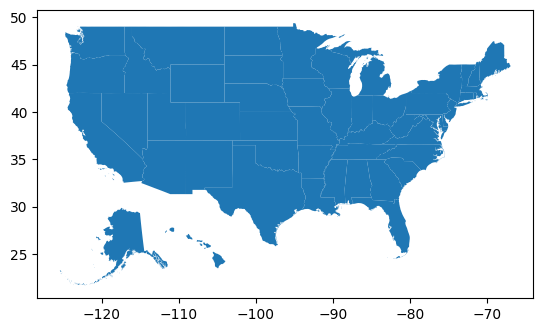

In [80]:
UStates.plot()
plt.show()
#plot shows up really tiny!

In [130]:
spooky_US = pd.merge(UStates, spookyset, on='state',how='outer',indicator=True) #outer merging
spooky_US.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 51 non-null     object  
 1   fill-opacity       51 non-null     int32   
 2   stroke-opacity     51 non-null     int32   
 3   stroke             51 non-null     object  
 4   state_fips         51 non-null     object  
 5   state              51 non-null     object  
 6   state_name         51 non-null     object  
 7   geometry           51 non-null     geometry
 8   state_name_x       51 non-null     object  
 9   UFO_sight          51 non-null     int64   
 10  haunted_house      51 non-null     int64   
 11  Vacant24MO         51 non-null     float64 
 12  Total Area Sq.Mi.  51 non-null     int64   
 13  POPESTIMATE2024    51 non-null     int64   
 14  BIRTHS2024         51 non-null     int64   
 15  DEATHS2024         51 non-null     int64   
 16  uf

#UFO Reports per State

<Axes: >

[]

[]

Text(0.5, 1117.767960045528, 'source/definition: nuforc.org/databank/')

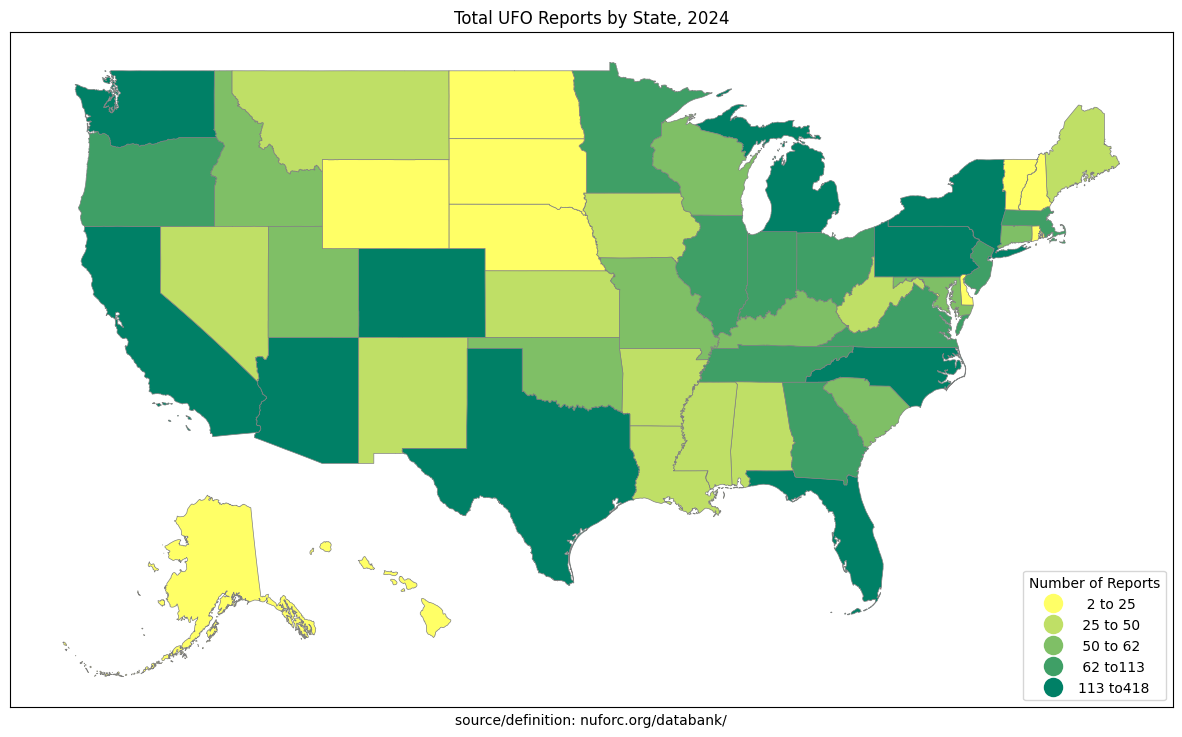

In [131]:
fig, ax = plt.subplots(1, figsize=(15, 30))
ax.set_aspect('equal')
spooky_US.plot(ax=ax,column='UFO_sight',legend=True,cmap='summer_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.5,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
leg1 = ax.get_legend()
leg1.set_title('''Number of Reports''')
ax.title.set_text("Total UFO Reports by State, 2024")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('''source/definition: nuforc.org/databank/''')

for lbl in leg1.get_texts():
        label_text = lbl.get_text()
        new_text = label_text.replace(', ', ' to')
        lbl.set_text(new_text)

<Axes: >

[]

[]

Text(0.5, 1117.767960045528, 'source/definition: nuforc.org/databank/')

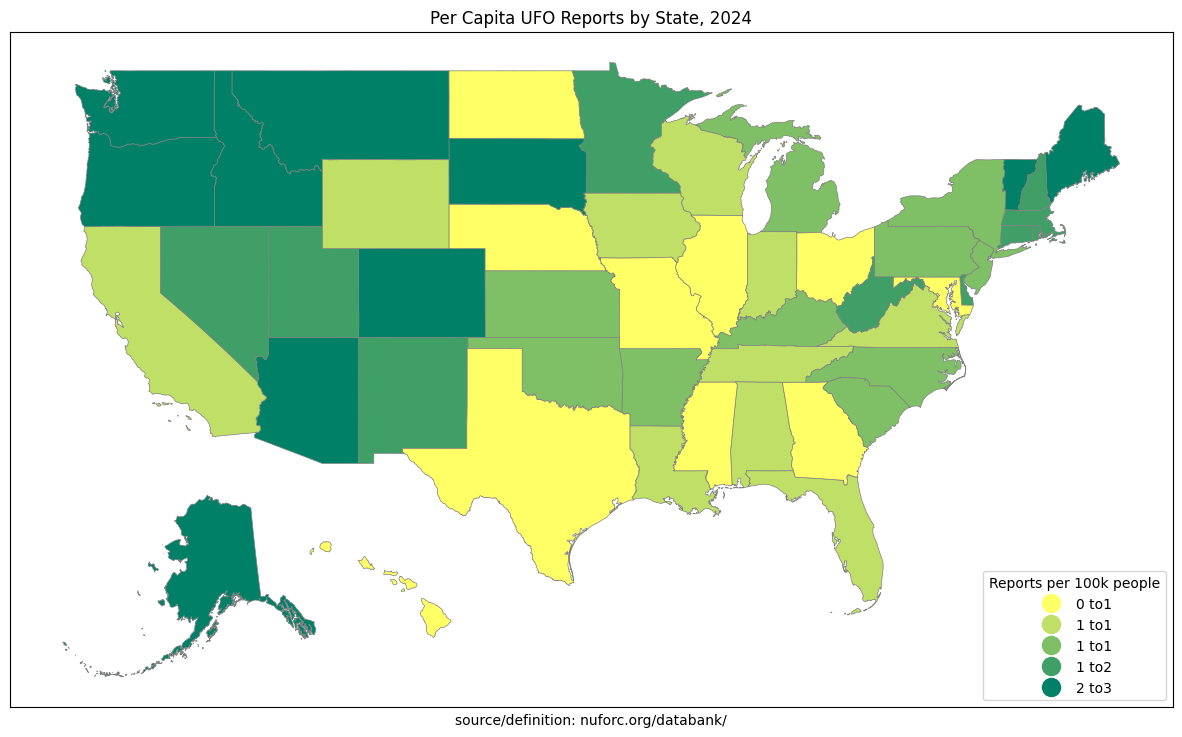

In [92]:
fig, ax = plt.subplots(1, figsize=(15, 30))
ax.set_aspect('equal')
spooky_US.plot(ax=ax,column='ufocap',legend=True,cmap='summer_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.5,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
leg1 = ax.get_legend()
leg1.set_title('''Reports per 100k people''')
ax.title.set_text("Per Capita UFO Reports by State, 2024")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('''source/definition: nuforc.org/databank/''')

for lbl in leg1.get_texts():
        label_text = lbl.get_text()
        new_text = label_text.replace(', ', ' to')
        lbl.set_text(new_text)

##Map of UFO Reports in 2024
The top 10 states with the most UFO reports appear in the deepest green: California, Florida, Texas, New York, Washington, Arizona, Pennsylvania, Colorado, Michigan, and North Carolina. </br>
However, when accounting for population, top reporters like California and Texas hold less weight than other states, averaging about one report per 100,000 residents. Instead, Alaska, Oregon, Idaho, Montana, South Dakota, Vermont, and Maine had 2-3 reports per 100k residents. Notably, Washington, Arizona, and Colorado were still among the top states, suggesting that a larger prcentage of people in these states have reported UFOs compared to other larger, more populated states.



<Axes: >

[]

[]

Text(0.5, 705.5567333750474, 'source: nuforc.org/databank/')

<Axes: >

[]

[]

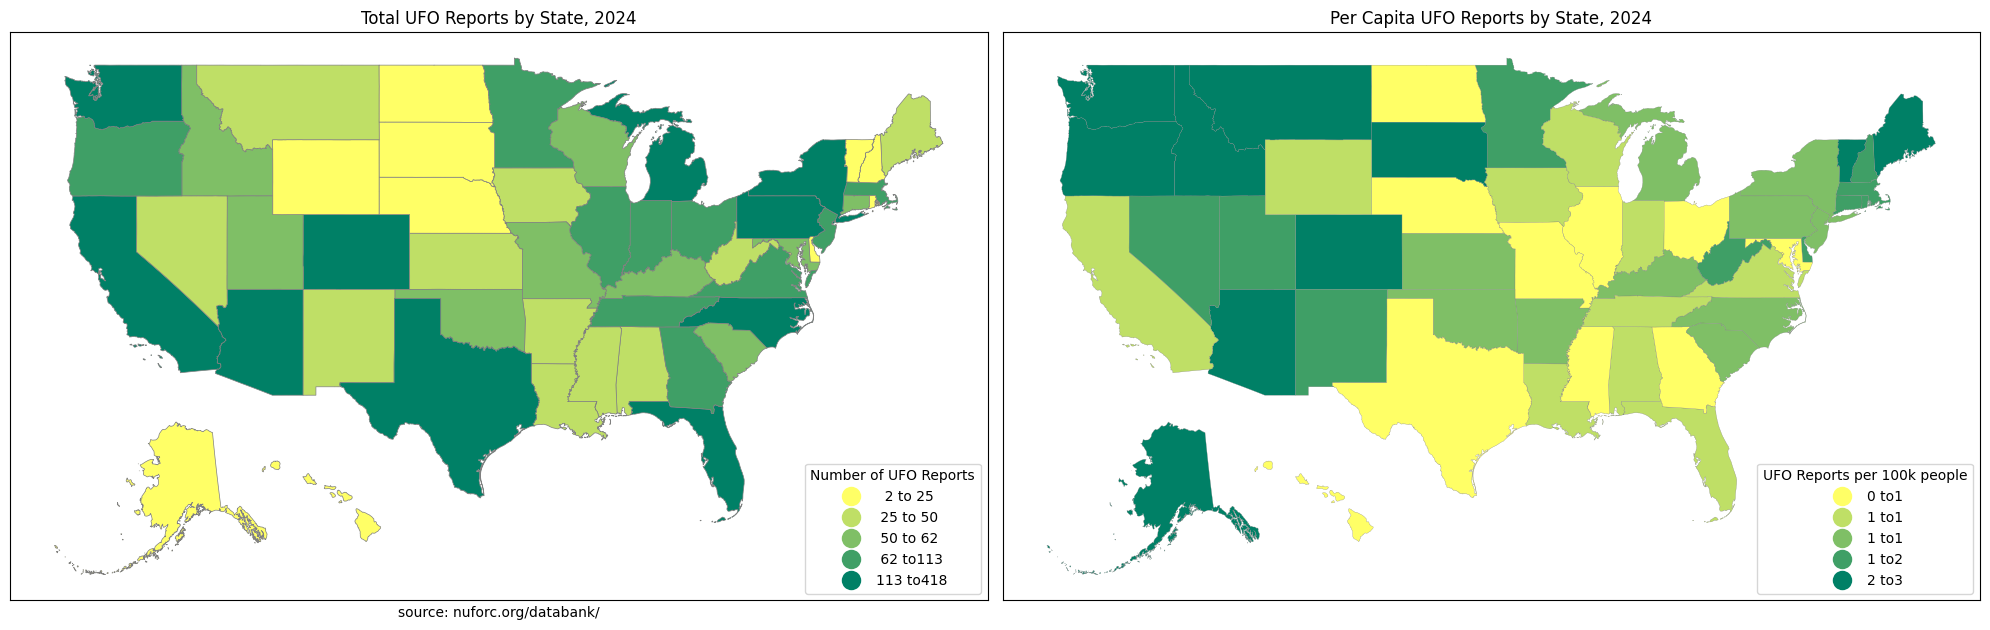

In [141]:
fig, axs = plt.subplots(1,2, figsize=(20,20),sharey=True, tight_layout=True)
spooky_US.plot(ax=axs[0],column='UFO_sight',legend=True,cmap='summer_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.5,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
axs[0].title.set_text("Total UFO Reports by State, 2024")
axs[0].set_xticks([]); axs[0].set_yticks([])
axs[0].set_xlabel('''source: nuforc.org/databank/''')
leg1_ufo = axs[0].get_legend()
leg1_ufo.set_title('''Number of UFO Reports''')


spooky_US.plot(ax=axs[1],column='ufocap',legend=True,cmap='summer_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
axs[1].title.set_text("Per Capita UFO Reports by State, 2024")
axs[1].set_xticks([]); axs[1].set_yticks([])
leg1_haunted = axs[1].get_legend()
leg1_haunted.set_title('''UFO Reports per 100k people''')

#Add decimals to values here
for ax in axs:
  for lbl in ax.get_legend().get_texts():
        label_text = lbl.get_text()
        new_text = label_text.replace(', ', ' to')
        lbl.set_text(new_text)

In [154]:
from matplotlib.patheffects import withStroke

In [159]:
mapc = UStates.copy()
mapc["geometry"] = mapc["geometry"].to_crs(epsg=4326)
mapc["geometry"]=mapc["geometry"].centroid

/tmp/ipython-input-108002779.py:3: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




In [176]:
alien = print("\U0001F47D")
alien

👽


In [178]:
import emoji

ModuleNotFoundError: No module named 'emoji'

<Axes: >

[]

[]

Text(0.5, 705.5567333750474, 'source: nuforc.org/databank/')

/tmp/ipython-input-154442641.py:12: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




...

<Axes: >

[]

[]

/tmp/ipython-input-154442641.py:25: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

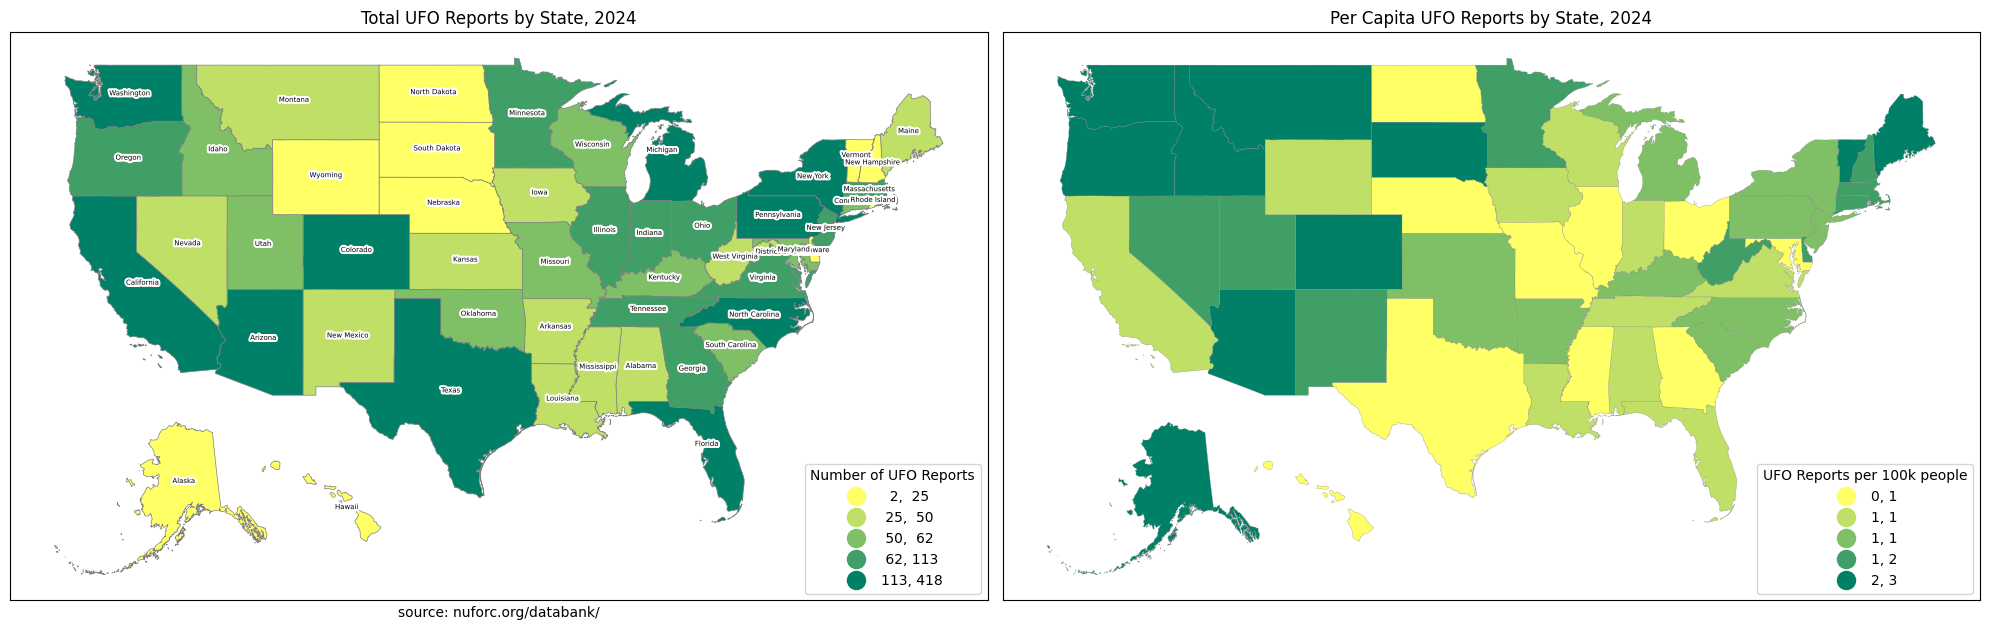

In [181]:
fig, axs = plt.subplots(1,2, figsize=(20,20),sharey=True, tight_layout=True)
spooky_US.plot(ax=axs[0],column='UFO_sight',legend=True,cmap='summer_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.5,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
axs[0].title.set_text("Total UFO Reports by State, 2024")
axs[0].set_xticks([]); axs[0].set_yticks([])
axs[0].set_xlabel('''source: nuforc.org/databank/''')
leg1_ufo = axs[0].get_legend()
leg1_ufo.set_title('''Number of UFO Reports''')

for x, y, label in zip(njP.geometry.x, njP.geometry.y, njP.COUNTY):
    axs[0].annotate(label, xy=(x, y),horizontalalignment='center',
    fontsize=5,color='black', #fontweight='bold',
    path_effects=[withStroke(linewidth=3, foreground='white')]) #ytext=(3, 3), textcoords="offset points"


spooky_US.plot(ax=axs[1],column='ufocap',legend=True,cmap='summer_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
axs[1].title.set_text("Per Capita UFO Reports by State, 2024")
axs[1].set_xticks([]); axs[1].set_yticks([])
leg1_haunted = axs[1].get_legend()
leg1_haunted.set_title('''UFO Reports per 100k people''')

#Add decimals to values here
for ax in axs:
  for lbl in ax.get_legend().get_texts():
        label_text = lbl.get_text()
        new_text = label_text.replace(', ', ' to')
        lbl.set_text(new_text)

In [182]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.6 MB/s eta 0:00:00


<Axes: >

[]

[]

Text(0.5, 705.5567333750474, 'source: nuforc.org/databank/')

/tmp/ipython-input-3581176140.py:15: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




...

Text(-100.23044797642672, 43.43613089653843, '2.1629361425547953')

Text(-72.66271933121287, 44.07519851002375, 'Vermont')

Text(-72.66271933121287, 43.07519851002375, '2.7756660441978553')

Text(-120.45086011857661, 47.38228437345569, 'Washington')

Text(-120.45086011857661, 46.38228437345569, '2.387480554599167')

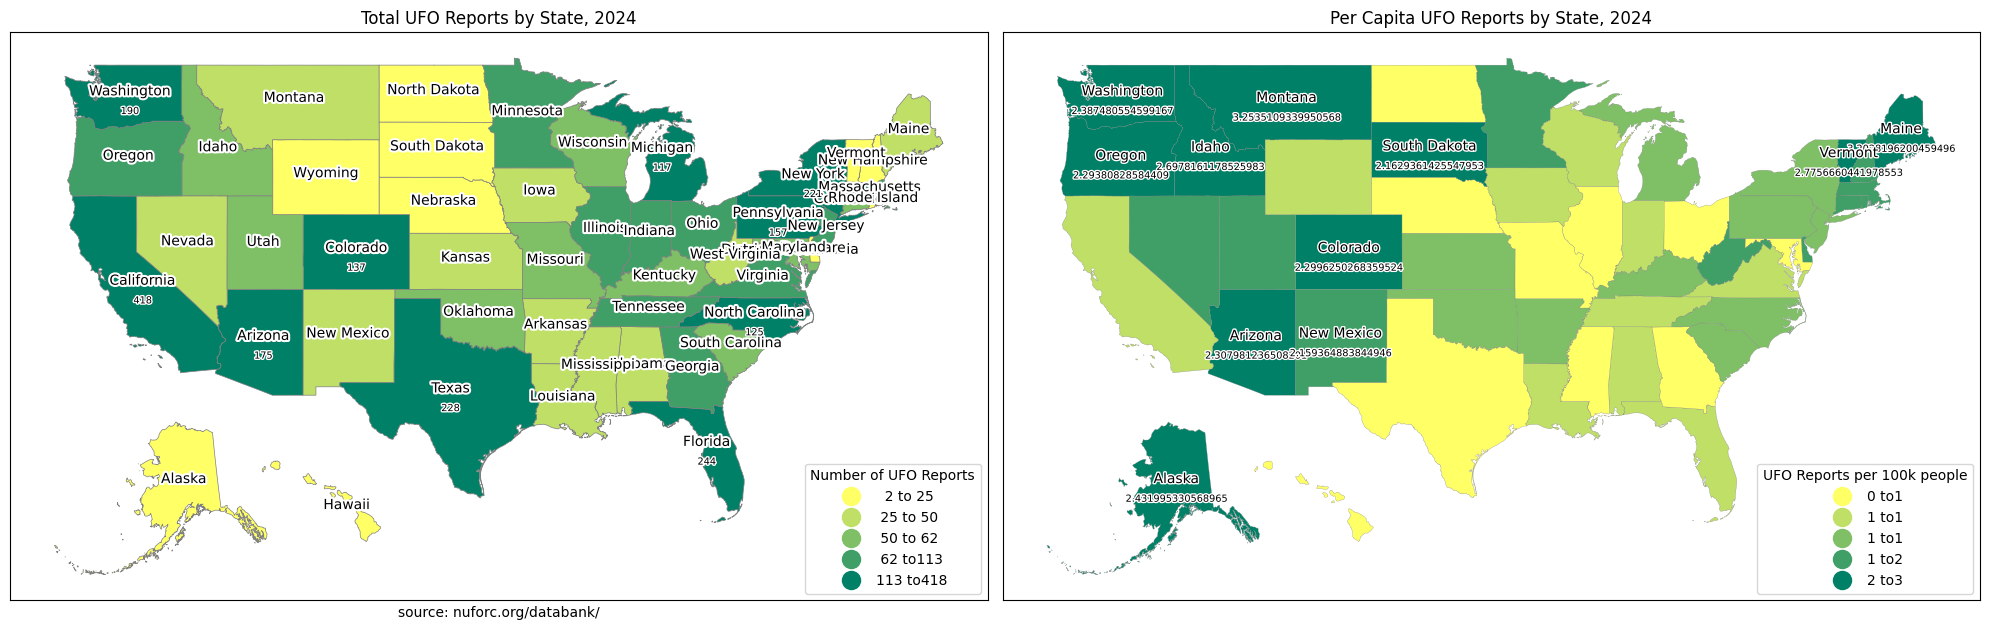

In [194]:
import emoji
from matplotlib.patheffects import withStroke

fig, axs = plt.subplots(1,2, figsize=(20,20),sharey=True, tight_layout=True)
spooky_US.plot(ax=axs[0],column='UFO_sight',legend=True,cmap='summer_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.5,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
axs[0].title.set_text("Total UFO Reports by State, 2024")
axs[0].set_xticks([]); axs[0].set_yticks([])
axs[0].set_xlabel('''source: nuforc.org/databank/''')
leg1_ufo = axs[0].get_legend()
leg1_ufo.set_title('''Number of UFO Reports''')

# Add state labels to the first subplot
for x, y, label in zip(spooky_US.geometry.centroid.x, spooky_US.geometry.centroid.y, spooky_US.state_name):
    axs[0].annotate(label, xy=(x, y),horizontalalignment='center',
    fontsize=10,color='black', #fontweight='bold',
    path_effects=[withStroke(linewidth=3, foreground='white')]) #ytext=(3, 3), textcoords="offset points"

for x, y, report_value in zip(spooky_US.geometry.centroid.x, spooky_US.geometry.centroid.y, spooky_US.UFO_sight):
    if report_value > 113:
        axs[0].annotate(report_value, xy=(x, y-1), horizontalalignment='center',
                       fontsize=7, color='black',
                       path_effects=[withStroke(linewidth=2, foreground='white')])


spooky_US.plot(ax=axs[1],column='ufocap',legend=True,cmap='summer_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
axs[1].title.set_text("Per Capita UFO Reports by State, 2024")
axs[1].set_xticks([]); axs[1].set_yticks([])
leg1_haunted = axs[1].get_legend()
leg1_haunted.set_title('''UFO Reports per 100k people''')

# Add alien emoji to states with ufocap > 2
for x, y, ufocap_value, label in zip(spooky_US.geometry.centroid.x, spooky_US.geometry.centroid.y, spooky_US.ufocap, spooky_US.state_name):
    if ufocap_value > 2:
        axs[1].annotate(label, xy=(x, y), horizontalalignment='center',
                       fontsize=10, color='black',
                       path_effects=[withStroke(linewidth=2, foreground='white')])
        axs[1].annotate(ufocap_value, xy=(x, y-1), horizontalalignment='center',
                       fontsize=7, color='black',
                       path_effects=[withStroke(linewidth=2, foreground='white')])


#Add decimals to values here
for ax in axs:
  for lbl in ax.get_legend().get_texts():
        label_text = lbl.get_text()
        new_text = label_text.replace(', ', ' to')
        lbl.set_text(new_text)

plt.show()

In [152]:
#from AI https://www.google.com/search?q=interactive+pandas+map+plot+shapefile&sca_esv=7996920a3193b21b&rlz=1C1GEWG_enUS1074US1075&ei=yyEMadu1N9qj5NoPoOvegAw&ved=0ahUKEwibx8b11dyQAxXaEVkFHaC1F8AQ4dUDCBE&uact=5&oq=interactive+pandas+map+plot+shapefile&gs_lp=Egxnd3Mtd2l6LXNlcnAiJWludGVyYWN0aXZlIHBhbmRhcyBtYXAgcGxvdCBzaGFwZWZpbGUyBRAhGKABMgUQIRigATIFECEYoAEyBRAhGKABMgUQIRifBTIFECEYnwUyBRAhGJ8FMgUQIRifBTIFECEYnwUyBRAhGJ8FSMwhUKUHWKIgcAF4AZABAJgBeqAB7weqAQM1LjW4AQPIAQD4AQGYAgugAtwIwgIKEAAYsAMY1gQYR8ICBRAhGKsCmAMAiAYBkAYIkgcDMy44oAerMbIHAzIuOLgHyAjCBwcwLjEuOC4yyAdA&sclient=gws-wiz-serp
%%capture
import plotly.express as px
fig = px.choropleth_mapbox(spooky_US,
                               geojson=spooky_US.geometry,
                               locations=spooky_US.index, # Or a unique identifier column
                               color="ufocap",
                               mapbox_style="carto-positron",
                               zoom=3, center={"lat": 37.0902, "lon": -95.7129},
                               opacity=0.5,
                               hover_name="state_name")
fig.show()

In [153]:
%%capture
# Got this from https://geopandas.org/en/stable/docs/user_guide/interactive_mapping.html
import folium

ufomap = spooky_US.explore(
    column="ufocap",  # make choropleth based on variable
    cmap= "summer_r",
    scheme="quantiles",  # break desired
    legend=True,  # show legend
    k=5,  # use 5 bins
    tooltip=False,  # hide tooltip
    popup=["state_name", "ufocap"],  # show popup (on-click)
    legend_kwds=dict(colorbar=False),  # do not use colorbar
    name="Reports per 100k",  # name of the layer in the map
)

ufomap  # show map

In [140]:
#Tried using these instructions (https://plotly.com/python/choropleth-maps/) but none worked

#from urllib.request import urlopen
import json
#with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    #counties = json.load(response)

#import pandas as pd
#df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/fips-unemp-16.csv",
                   #dtype={"fips": str})

import plotly.express as px

fig = px.choropleth(spooky_US, geojson=UStates, locations='id', color='ufocap',
                           color_continuous_scale="Viridis",
                           range_color=(0, 12),
                           scope="usa",
                           labels={'state_name_x':'ufocap'}
                          )
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

#Haunted Places per State

<Axes: >

[]

[]

Text(0.5, 1117.767960045528, 'source/definition: tidytuesday/blob/main/data/2023/2023-10-10')

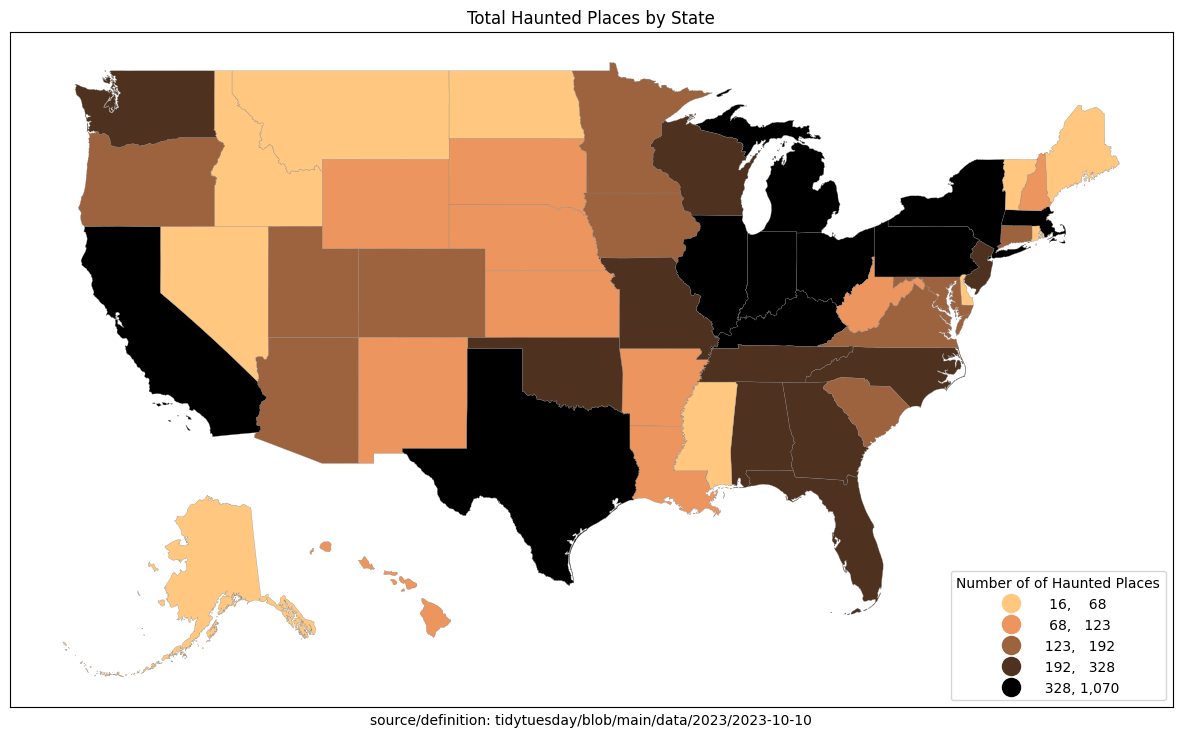

In [ ]:
fig, ax = plt.subplots(1, figsize=(15, 30))
ax.set_aspect('equal')
spooky_US.plot(ax=ax,column='haunted_house',legend=True,cmap='copper_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
leg1 = ax.get_legend()
leg1.set_title('''Number of of Haunted Places''')
ax.title.set_text("Total Haunted Places by State")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/definition: tidytuesday/blob/main/data/2023/2023-10-10''')

<Axes: >

[]

[]

Text(0.5, 1117.767960045528, 'source/definition: tidytuesday/blob/main/data/2023/2023-10-10')

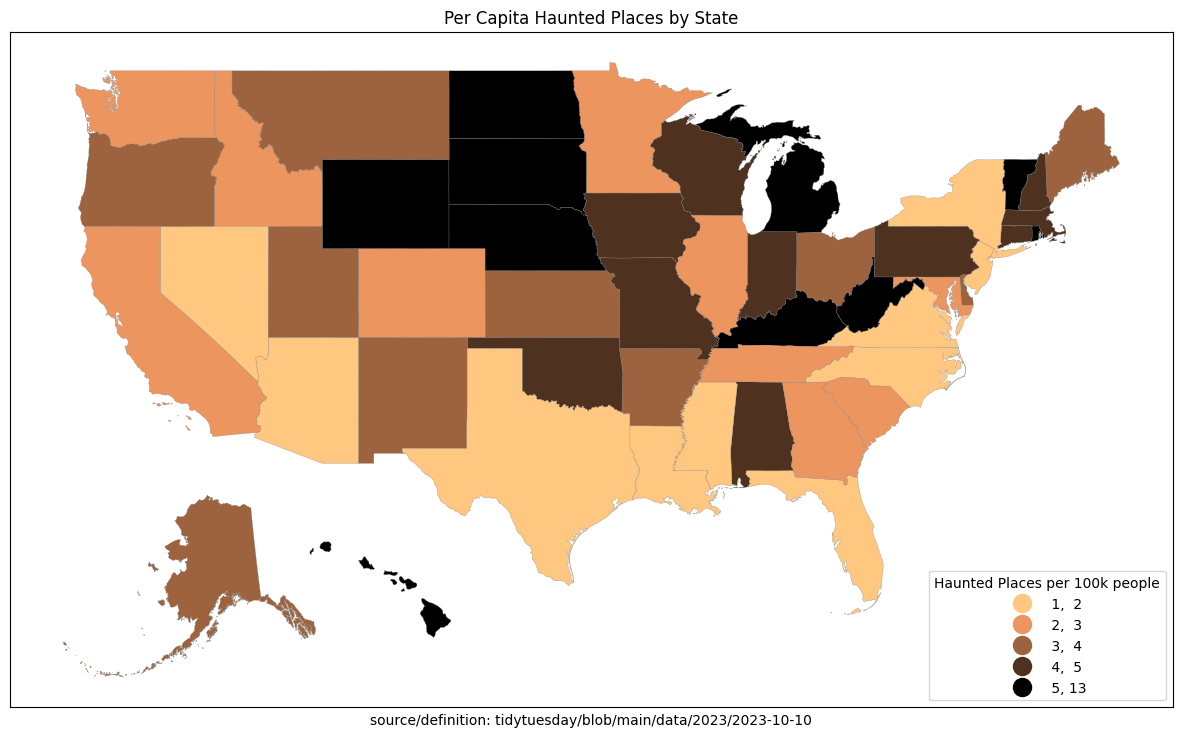

In [ ]:
fig, ax = plt.subplots(1, figsize=(15, 30))
ax.set_aspect('equal')
spooky_US.plot(ax=ax,column='hauntedcap',legend=True,cmap='copper_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
leg1 = ax.get_legend()
leg1.set_title('''Haunted Places per 100k people''')
ax.title.set_text("Per Capita Haunted Places by State")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/definition: tidytuesday/blob/main/data/2023/2023-10-10''')

##Map of Haunted Places by State
The top 10 states with the most haunted places appear in black: California, Texas, Pennsylvania, Michigan, Ohio, New York, Illinois, Kentucky, Indiana, and Massachussetts. Only California, Texas, and Pennsylvania have 650 places or more. Most states have fewer than 250 haunted places. </br>
When accounting for population though, Hawaii, Wyoming, North and South Dakota, Nebraska, West Virginia, and Rhode Island come up top with 5-13 haunted places per 100,000 people. Notably, Michigan and Kentucky remain at the top quintile still, and Vermont (one of the top for UFO reports per capita) also has a high density of haunted places in terms of population.

<Axes: >

[]

[]

Text(0.5, 705.5567333750474, 'source/definition: nuforc.org/databank/')

<Axes: >

[]

[]

Text(0.5, 686.5499286499914, 'source/definition: tidytuesday/blob/main/data/2023/2023-10-10')

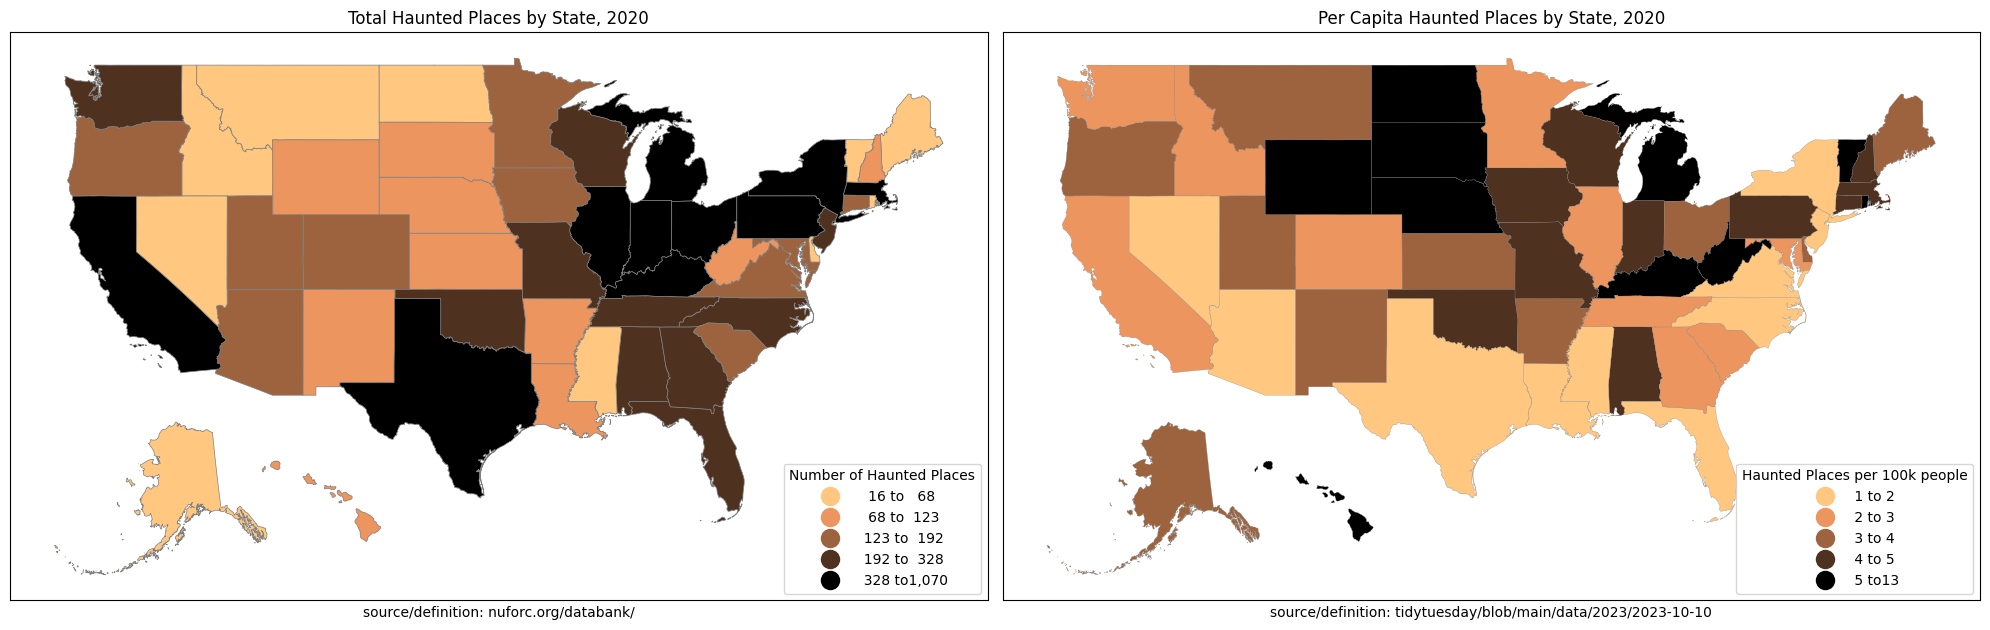

In [ ]:
#Reconsider how useful a per capita breakdown is for this
#Make interactive
fig, axs = plt.subplots(1,2, figsize=(20,20),sharey=True, tight_layout=True)
spooky_US.plot(ax=axs[0],column='haunted_house',legend=True,cmap='copper_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.5,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
axs[0].title.set_text("Total Haunted Places by State, 2020")
axs[0].set_xticks([]); axs[0].set_yticks([])
axs[0].set_xlabel('''source/definition: nuforc.org/databank/''')
leg1_ufo = axs[0].get_legend()
leg1_ufo.set_title('''Number of Haunted Places''')


spooky_US.plot(ax=axs[1],column='hauntedcap',legend=True,cmap='copper_r',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
axs[1].title.set_text("Per Capita Haunted Places by State, 2020")
axs[1].set_xticks([]); axs[1].set_yticks([])
axs[1].set_xlabel('''source/definition: tidytuesday/blob/main/data/2023/2023-10-10''')
leg1_haunted = axs[1].get_legend()
leg1_haunted.set_title('''Haunted Places per 100k people''')

for ax in axs:
  for lbl in ax.get_legend().get_texts():
        label_text = lbl.get_text()
        new_text = label_text.replace(', ', ' to')
        lbl.set_text(new_text)

In [ ]:
ax = sns.histplot(ufo["mpg"], bins=20)
# Add rug on horizontal axis
sns.rugplot(auto["mpg"], height=0.05, color="red", ax=ax);

#Long-term vacancies by state


<Axes: >

[]

[]

Text(0.5, 510.1165393199635, 'source/definition: ACS 2024 Estimates US Census')

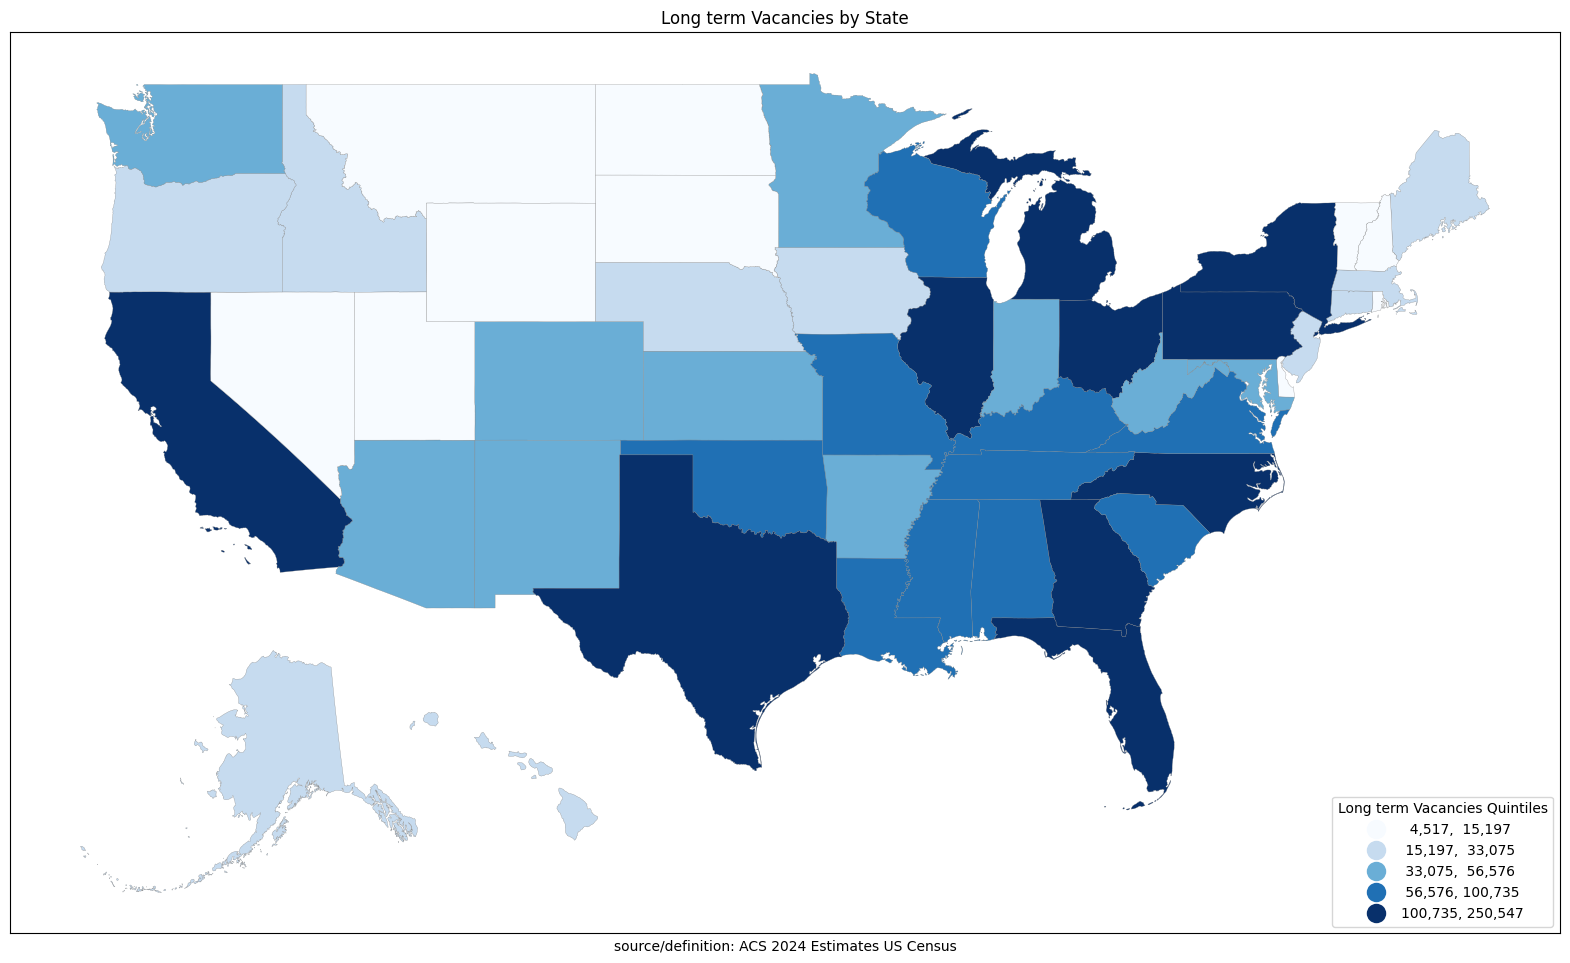

In [ ]:
#spooky_US['Vacant24MO'] = pd.to_numeric(spooky6['Vacant24MO'], errors='coerce')
#spooky6 = spooky6.dropna(subset=['Vacant24MO'])

fig, ax = plt.subplots(1, figsize=(20, 20))
ax.set_aspect('equal')
spooky_US.plot(ax=ax,column='Vacant24MO',legend=True,cmap='Blues',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
leg1 = ax.get_legend()
leg1.set_title('''Long term Vacancies Quintiles''')
ax.title.set_text("Long term Vacancies by State")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/definition: ACS 2024 Estimates US Census''')

<Axes: >

[]

[]

Text(0.5, 510.1165393199635, 'source/definition: ACS 2024 Estimates US Census')

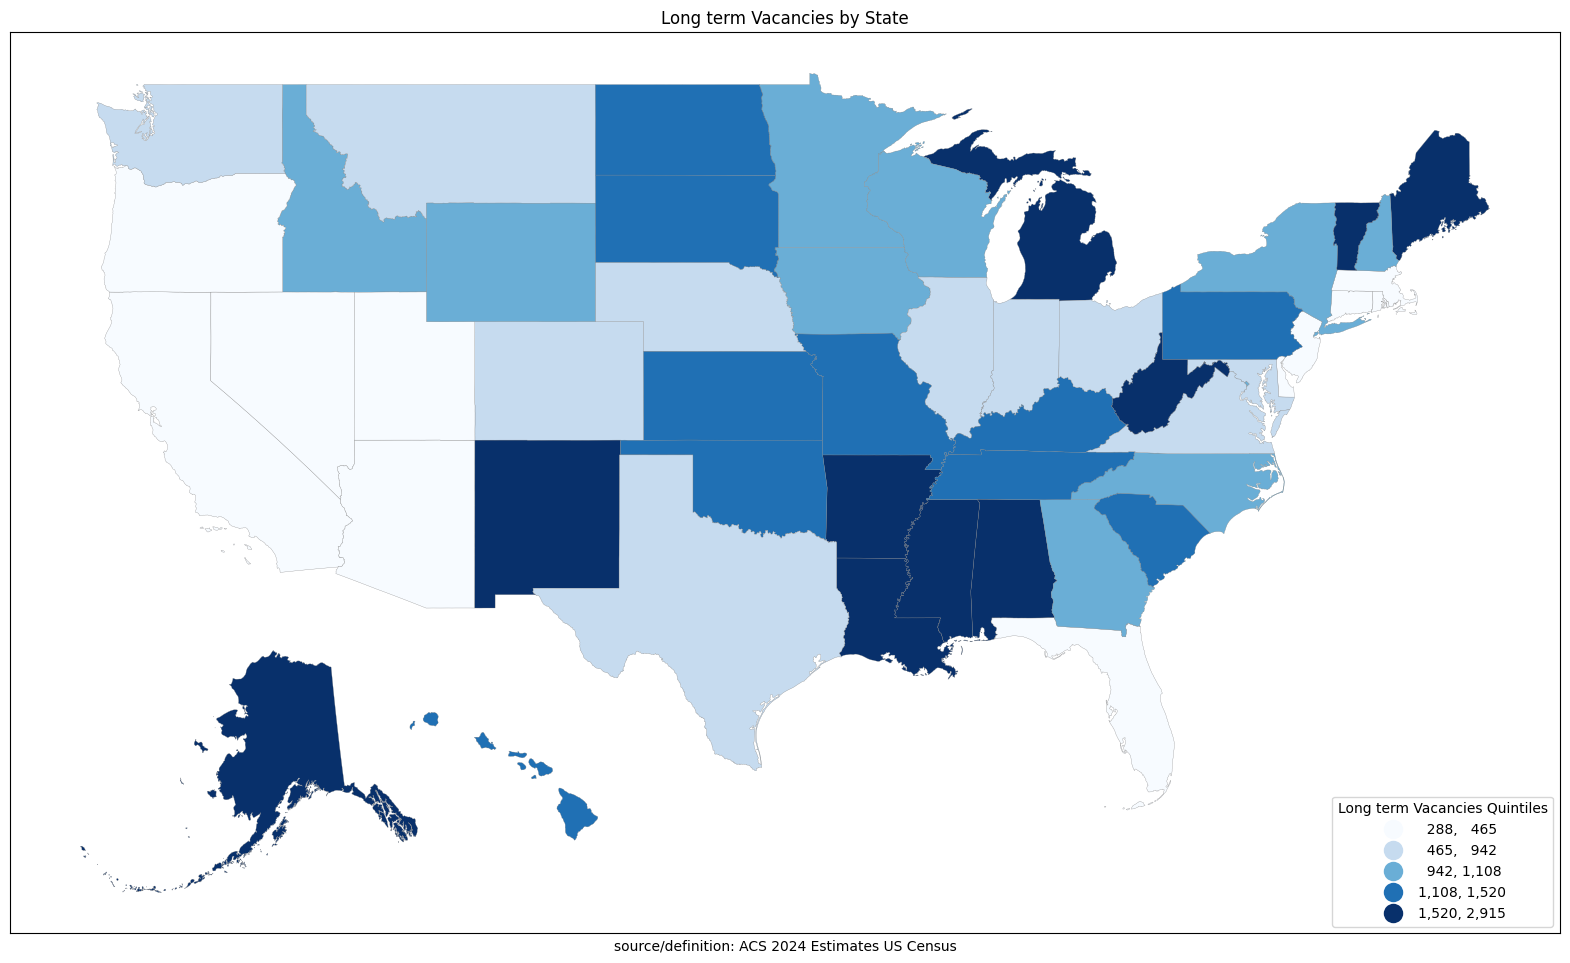

In [ ]:
#Would be cool to see this with ghost towns
fig, ax = plt.subplots(1, figsize=(20, 20))
ax.set_aspect('equal')
spooky_US.plot(ax=ax,column='vacap',legend=True,cmap='Blues',
          scheme='quantiles',k=5, edgecolor='grey',linewidth=.2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
leg1 = ax.get_legend()
leg1.set_title('''Long term Vacancies Quintiles''')
ax.title.set_text("Long term Vacancies by State")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/definition: ACS 2024 Estimates US Census''')

##Map of Long-term Vacancies by State